# EDA y Limpieza: Banco 2 — BR Privado

**Dataset:** `Copia de 02_br_privado_seed33_n100000.csv`  
**Output:** `br_privado_clean.csv` en `proyecto_plus_ti/datasets/`

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Librerias listas')

Librerias listas


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_PLOTS    = PATH_PROJECT + 'plots_nb2/'
os.makedirs(PATH_PLOTS, exist_ok=True)

FILE = 'Copia de 02_br_privado_seed33_n100000.csv'
print(f'PATH: {PATH_DATASETS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH: /content/drive/MyDrive/proyecto_plus_ti/datasets/


In [3]:
df_br = pd.read_csv(PATH_DATASETS + FILE, sep=';', low_memory=False)
print(f'Banco 2 — BR Privado: {df_br.shape[0]:,} filas | {df_br.shape[1]} columnas')
display(df_br.head(3))

Banco 2 — BR Privado: 100,000 filas | 66 columnas


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,...,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,49b290bb-4479-4367-950d-ed7d9bdc96d0,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00003011,CLASICA,POS,VISA,422355******4250,cde43f85cf5ec9d005e8a539bc2e540a442e43af7a5577...,100,4223550000000000.0000,0,7461,7461,101000221,10000000.0000,749972,210221,1231,2705,101.0000,7832,76,...,Y,NaN,Y,NaN,8881828076.0000,POS-ATTENDED,0.0000,BR-PRI,8881828076.0000,ACC762765677939,NaN,05100Y,74.6100,74.6100,BRL,14.9200,False,12.1000,21,Tue,True,Approved,714.7400,CURITIBA,False
1,0697c7b6-b5ab-4ab5-8684-4f3fcdd54ff2,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00000292,ORO,POS,VISA,422355******2908,b1a76140549f19c2367462d823e0d2d1897c53e3968b9e...,100,4223560000000000.0000,0,29162,29162,101000350,10000000.0000,751009,210350,1231,2902,101.0000,5541,76,...,Y,NaN,Y,NaN,8881828076.0000,POS-ATTENDED,0.0000,BR-PRI,8881828076.0000,ACC091899892764,NaN,05100Y,291.6200,291.6200,BRL,58.3200,False,2.1000,21,Tue,True,Approved,640.6700,CURITIBA,False
2,ac73c4c0-ca7d-48b8-ad18-ab6dcc48819c,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00002993,CLASICA,ATM,MASTERCARD,541333******2878,c5f1cc61d76ee0c47fca1b4bab64fa773df3cbf9e00dfe...,100,5413340000000000.0000,10000,24950,24950,101000533,10000000.0000,693786,210533,1231,2610,101.0000,6011,76,...,Y,NaN,Y,NaN,8881828076.0000,ATM-UNATTENDED,0.0000,BR-PRI,8881828076.0000,ACC796431724778,NaN,05100Y,249.5000,249.5000,BRL,49.9000,False,1086.0000,21,Tue,True,Approved,626.3200,RECIFE,False


## 1. Exploración de Datos

In [4]:
# Conversion is_fraud a int
fi = df_br['is_fraud'].map({'True':1,'False':0,True:1,False:0,1:1,0:0}).fillna(0).astype(int)

print('Valores unicos is_fraud:', df_br['is_fraud'].unique())
print(f'Fraudes: {fi.sum():,} | Legitimas: {(fi==0).sum():,}')
pct_fraud = round(fi.mean()*100, 2)
print('Tasa de fraude:', str(pct_fraud) + '%')

# Nulos
nul = (df_br.isnull().mean()*100).round(2)
nul_top = nul[nul>0].sort_values(ascending=False)
print(f'Columnas con nulos: {len(nul_top)} de {df_br.shape[1]}')
display(nul_top.head(20).to_frame('pct_nulos').style.background_gradient(cmap='OrRd', vmin=0, vmax=100))

Valores unicos is_fraud: [False  True]
Fraudes: 3,205 | Legitimas: 96,795
Tasa de fraude: 3.2%
Columnas con nulos: 23 de 66


,pct_nulos
DE56_original_data,100.000000
DE54_additional_amounts,100.000000
DE48_additional_data,100.000000
DE103_account_id_2,100.000000
DE44_additional_response_data,97.500000
DE38_authorization_code,2.500000
response_description,1.060000
client_segment,1.040000
DE15_settlement_date,1.030000
DE63_network_specific,1.020000


### Distribución de Clases y Montos


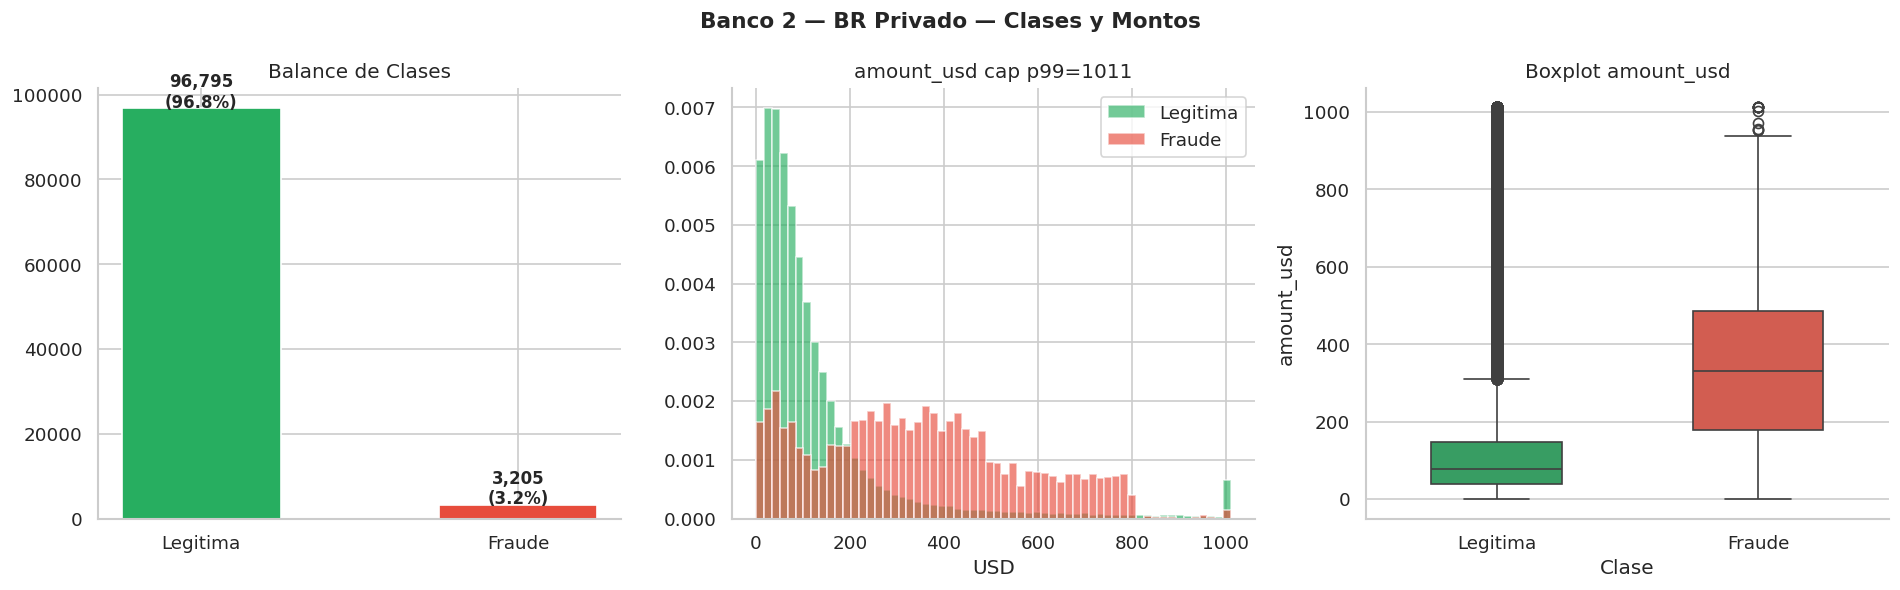

Guardado: 01_clases_montos.png


In [6]:
COLORS = {'Legitima':'#27ae60', 'Fraude':'#e74c3c'}
cap = df_br['amount_usd'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banco 2 — BR Privado — Clases y Montos', fontsize=13, fontweight='bold')

# Balance de clases
cnt  = fi.value_counts().sort_index()
lbls = {0:'Legitima', 1:'Fraude'}
bars = axes[0].bar([lbls[k] for k in cnt.index], cnt.values,
                   color=[COLORS[lbls[k]] for k in cnt.index],
                   width=0.5, edgecolor='white')
for b, v in zip(bars, cnt.values):
    pct = round(v/len(df_br)*100, 1)
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{v:,}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Balance de Clases')
axes[0].spines[['top','right']].set_visible(False)

# Histograma
for cls, lbl in [(0,'Legitima'),(1,'Fraude')]:
    d = df_br.loc[fi==cls,'amount_usd'].clip(upper=cap)
    axes[1].hist(d, bins=60, alpha=0.65, color=COLORS[lbl], label=lbl, density=True)
axes[1].set_title(f'amount_usd cap p99={cap:.0f}')
axes[1].set_xlabel('USD'); axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Boxplot
df_box = pd.DataFrame({'amount_usd':df_br['amount_usd'].clip(upper=cap),                         'Clase':fi.map({0:'Legitima',1:'Fraude'})})
sns.boxplot(data=df_box, x='Clase', y='amount_usd', palette=COLORS, width=0.5, ax=axes[2])
axes[2].set_title('Boxplot amount_usd')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'01_clases_montos.png', bbox_inches='tight')
plt.show()
print('Guardado: 01_clases_montos.png')

BR Privado presenta una tasa de fraude de **3.21%** (3,205 fraudes), notablemente menor que BO VIP (4.92%). Ambos datasets son desbalanceados, pero BR lo es más.

La diferencia más relevante frente a BO VIP está en los **montos**: el p99 de BR es USD 1,011 vs USD 2,844 en BO VIP. Los clientes del segmento privado brasileño transaccionan en rangos menores que los VIP bolivianos. Sin embargo, el patrón se mantiene: **los fraudes tienen montos significativamente más altos que las transacciones legítimas** (mediana fraude ~USD 350 vs legítima ~USD 100), confirmando que el modelo debe priorizar la detección de montos altos independientemente del banco.

> La diferencia de escala en montos entre bancos justifica usar `amount_usd` como métrica universal en el dataset federado, en lugar de monedas locales.

### Análisis de Valores Nulos


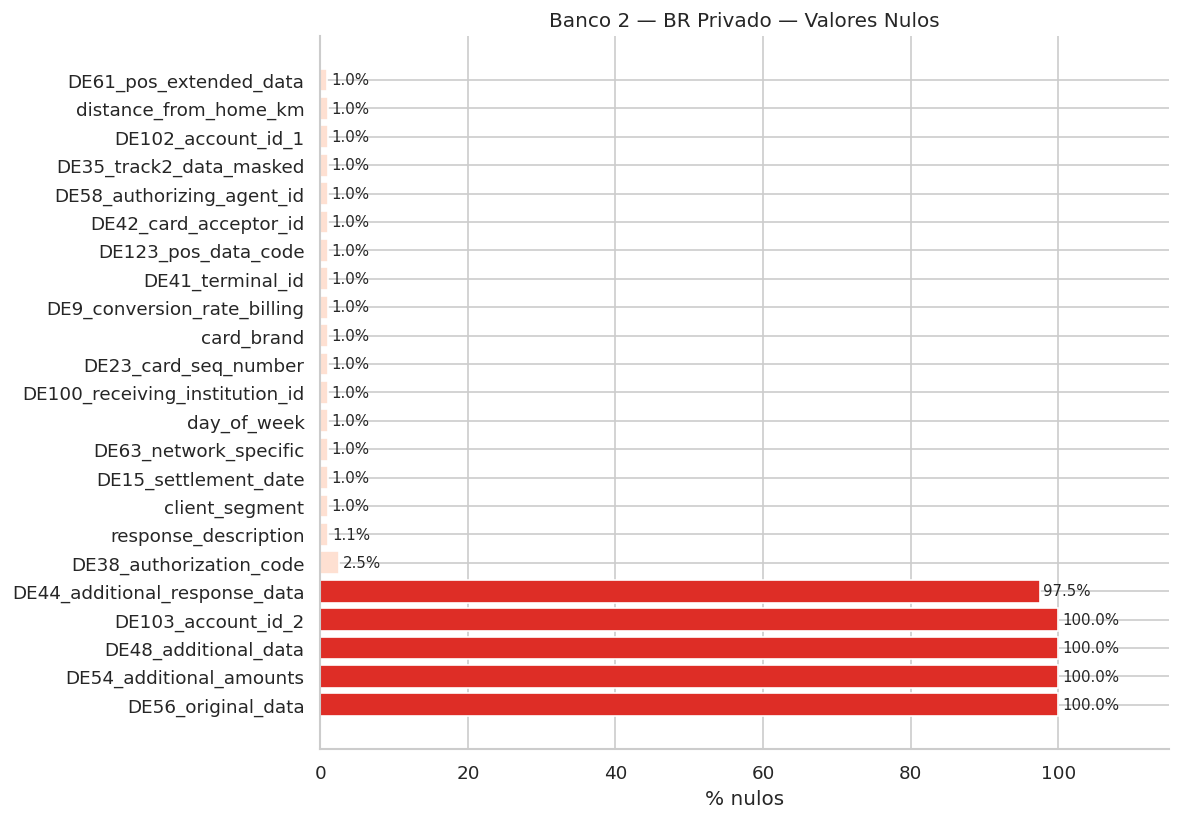

Guardado: 02_nulos.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
if len(nul_top):
    color_fn = lambda p: '#fee0d2' if p<30 else '#fc9272' if p<70 else '#de2d26'
    colors = [color_fn(p) for p in nul_top.values]
    bars = ax.barh(nul_top.index, nul_top.values, color=colors)
    for b, v in zip(bars, nul_top.values):
        ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlim(0, 115); ax.set_xlabel('% nulos')
    ax.spines[['top','right']].set_visible(False)
else:
    ax.text(0.5, 0.5, 'Sin columnas con nulos', ha='center', fontsize=14)
ax.set_title('Banco 2 — BR Privado — Valores Nulos', fontsize=12)
plt.tight_layout()
plt.savefig(PATH_PLOTS+'02_nulos.png', bbox_inches='tight')
plt.show()
print('Guardado: 02_nulos.png')

El patrón de nulos es **prácticamente idéntico al de BO VIP**, lo que indica que ambos bancos exportan sus datos desde el mismo sistema ISO 8583 con los mismos campos opcionales vacíos:

| Columna | BR Privado | BO VIP |
|---|---|---|
| `DE56`, `DE54`, `DE48`, `DE103` | 100% | 100% |
| `DE44_additional_response_data` | 97.5% | 96.7% |
| `DE38_authorization_code` | 2.5% | 3.3% |
| Resto | ~1% | ~1% |

La consistencia en los nulos entre bancos es una buena señal para el modelo federado: las mismas columnas serán eliminadas en ambos, resultando en estructuras compatibles.
### Patrones Temporales

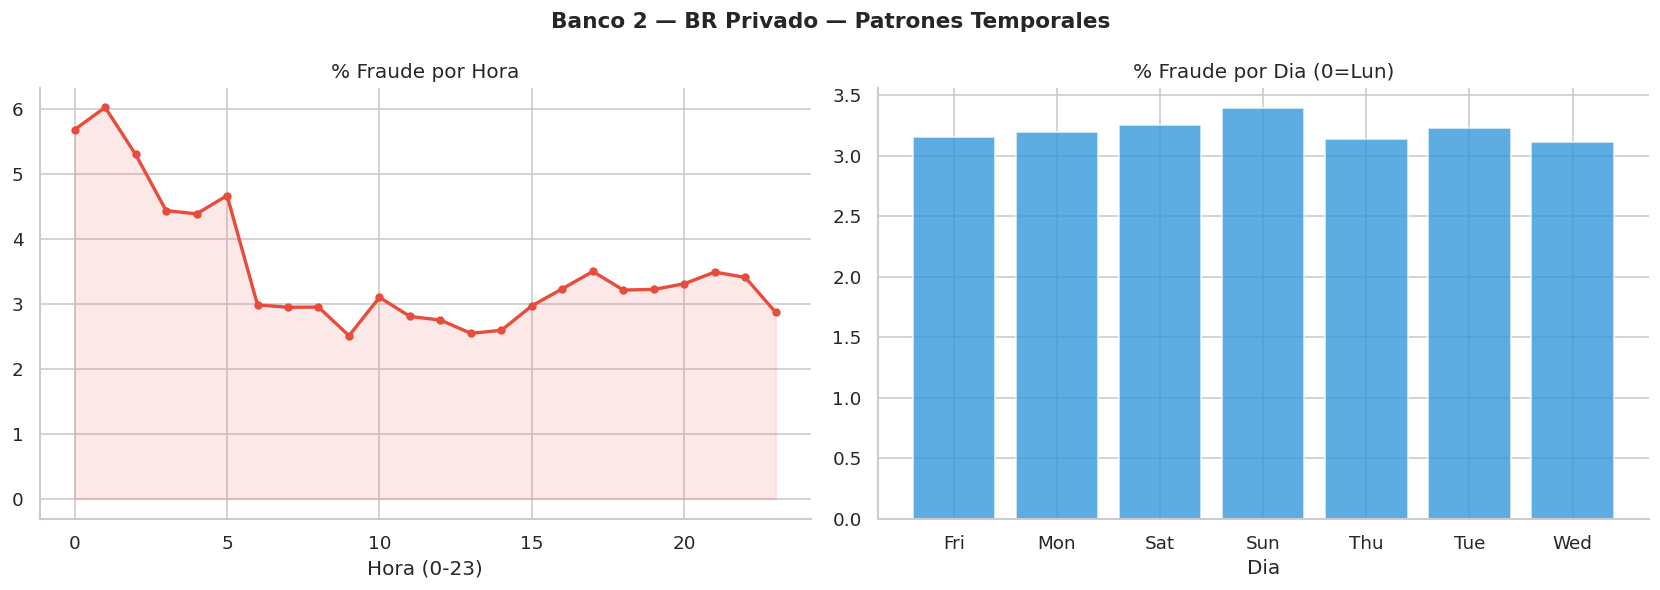

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Banco 2 — BR Privado — Patrones Temporales', fontsize=13, fontweight='bold')

df_t = df_br[['hour_local','day_of_week']].copy()
df_t['fraud'] = fi

t_hora = df_t.groupby('hour_local')['fraud'].mean() * 100
axes[0].plot(t_hora.index, t_hora.values, color='#e74c3c', lw=2, marker='o', ms=4)
axes[0].fill_between(t_hora.index, t_hora.values, alpha=0.12, color='#e74c3c')
axes[0].set_title('% Fraude por Hora'); axes[0].set_xlabel('Hora (0-23)')
axes[0].spines[['top','right']].set_visible(False)

t_dia = df_t.groupby('day_of_week')['fraud'].mean() * 100
axes[1].bar(t_dia.index, t_dia.values, color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_title('% Fraude por Dia (0=Lun)'); axes[1].set_xlabel('Dia')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'03_temporal.png', bbox_inches='tight')
plt.show()

**Por hora:** Al igual que BO VIP, BR Privado muestra el pico de fraude en horas de **madrugada (0–2h)**, alcanzando ~6%. Sin embargo, la caída es más pronunciada: a partir de las 6h la tasa baja a 2.5–3.5% y se mantiene estable, mientras que en BO VIP oscilaba más durante el día (~4–6%). BR es un banco más predecible en horario diurno.

**Por día de la semana:** Aquí aparece la diferencia más llamativa entre datasets. En BO VIP el **domingo tenía la tasa más baja** (~4.2%); en BR Privado el **domingo tiene la tasa MÁS ALTA** (~3.4%), con el resto de días casi planos (~3.1–3.2%). Esto sugiere que los perfiles de riesgo por día son específicos del banco y no generalizables, reforzando la decisión de **no incluir `day_of_week` como señal principal** en el modelo federado dado que su correlación con fraude es 0.00 en ambos datasets (no discrimina linealmente).
### Variables Categóricas

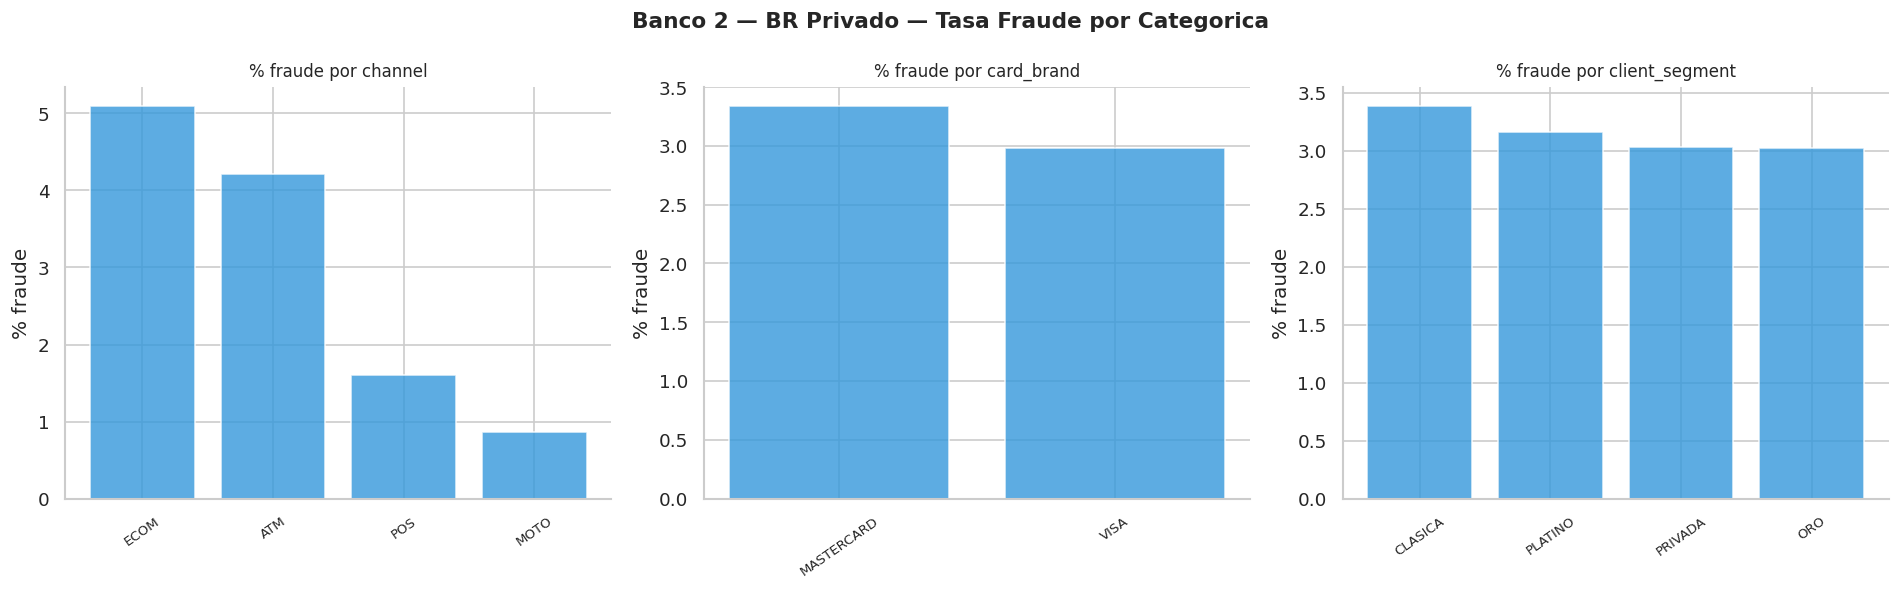

In [9]:
CAT_COLS = ['channel','card_brand','client_segment']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banco 2 — BR Privado — Tasa Fraude por Categorica', fontsize=13, fontweight='bold')

for ax, cat in zip(axes, CAT_COLS):
    if cat not in df_br.columns:
        ax.text(0.5,0.5,f'{cat}\nno disponible',ha='center',va='center')
        ax.set_title(cat); continue
    df_cat = df_br[[cat]].copy()
    df_cat['fraud'] = fi
    tasa = df_cat.groupby(cat)['fraud'].mean().sort_values(ascending=False)*100
    ax.bar(tasa.index.astype(str), tasa.values, color='#3498db', alpha=0.8, edgecolor='white')
    ax.set_title(f'% fraude por {cat}', fontsize=10)
    ax.set_ylabel('% fraude')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'04_categoricas.png', bbox_inches='tight')
plt.show()

**Canal (`channel`):** Se repite el patrón: **ECOM es el más fraudulento** (5.1%) seguido de ATM (4.2%). Importante: en BR el ATM tiene mayor peso relativo que en BO VIP (4.2% vs 2.9%), lo que podría reflejar mayor exposición a skimming en cajeros en el mercado brasileño.

**Marca de tarjeta (`card_brand`):** MASTERCARD (3.3%) vs VISA (3.0%), diferencia marginal idéntica a BO VIP. La marca no es predictor relevante en ninguno de los dos bancos.

**Segmento de cliente (`client_segment`):** BR usa una nomenclatura diferente (CLASICA, PLATINO, PRIVADA, ORO) vs BO VIP (PRIVATE, PLATINUM, BLACK, INFINITE). Las tasas son similares entre segmentos (~3.0–3.4%), sin diferencias marcadas. **Esta columna no puede usarse directamente en el modelo federado** al ser banco-específica — se eliminará junto con las demás columnas de sesgo en el otro notebook para generar el dataset final.
### Heatmap de Correlaciones

Valores únicos de day_of_week: ['Tue' 'Wed' nan 'Thu' 'Fri' 'Sat' 'Sun' 'Mon']


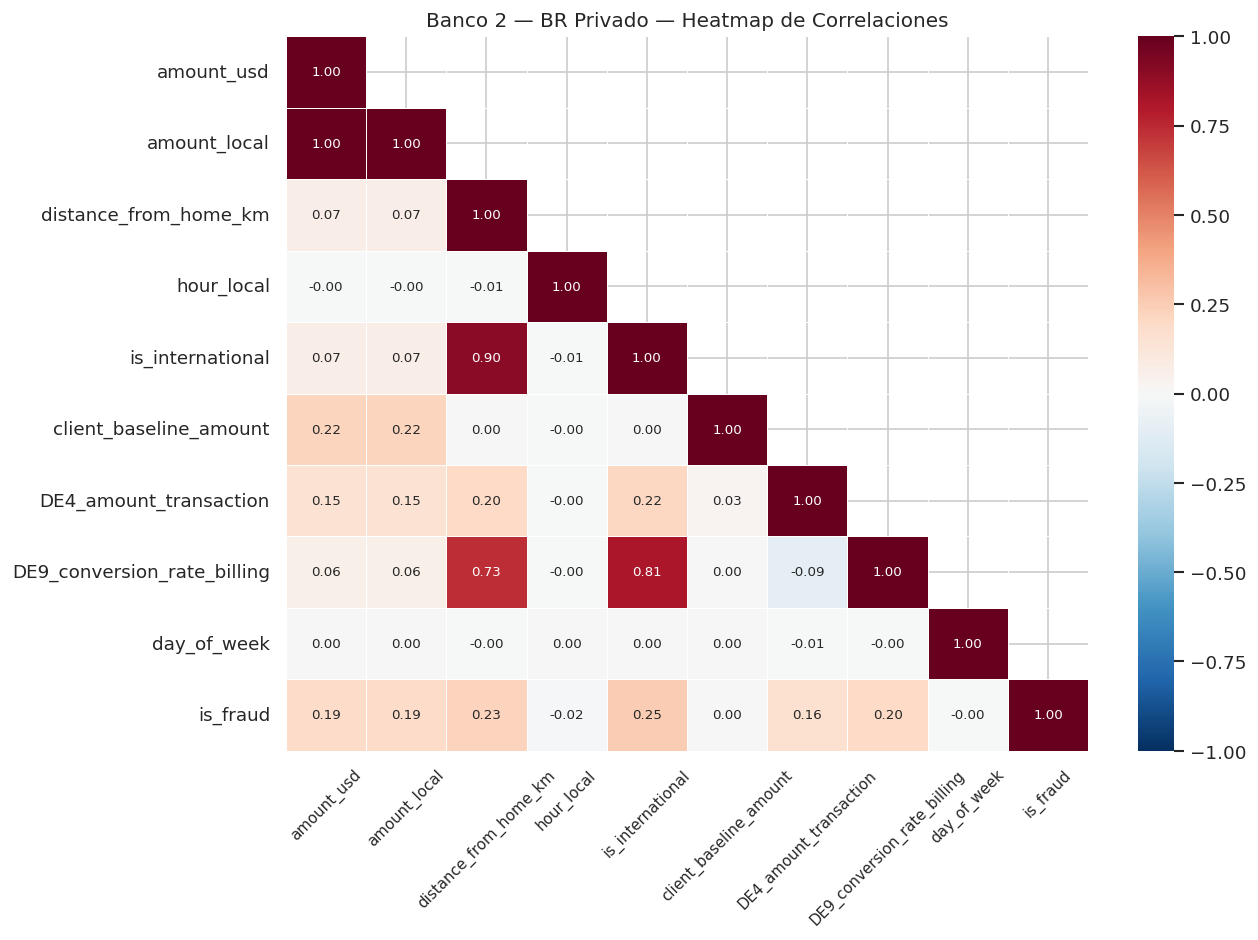

RIESGO FINANCIERO
  Fraudes: 3,205 | Total USD: 1,111,295.94
  Prom fraude: USD 346.74 | Prom legitimo: USD 133.92
  Con 90% deteccion: USD 1,000,166.35 rescatados


In [12]:
NUM_FEATS = ['amount_usd','amount_local','distance_from_home_km',
             'hour_local','is_international','client_baseline_amount',
             'DE4_amount_transaction','DE9_conversion_rate_billing']

df_c = df_br.copy()
df_c['is_fraud'] = fi

# Verificar y codificar day_of_week si es string
print("Valores únicos de day_of_week:", df_br['day_of_week'].unique()[:10])
if df_c['day_of_week'].dtype == object:
    # Codificación ordinal genérica por orden de aparición
    df_c['day_of_week'] = pd.Categorical(df_c['day_of_week']).codes
    NUM_FEATS = NUM_FEATS + ['day_of_week']

cols = [c for c in NUM_FEATS + ['is_fraud'] if c in df_c.columns]
df_c[cols] = df_c[cols].apply(pd.to_numeric, errors='coerce')

corr = df_c[cols].corr()

# k=1 → solo oculta triángulo SUPERIOR (mantiene diagonal visible)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size':8})
ax.set_title('Banco 2 — BR Privado — Heatmap de Correlaciones', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig(PATH_PLOTS+'05_heatmap.png', bbox_inches='tight')
plt.show()

# Resumen financiero
mask_f = fi==1
tot_f  = df_br.loc[mask_f,'amount_usd'].sum()
prom_f = df_br.loc[mask_f,'amount_usd'].mean()
prom_l = df_br.loc[~mask_f,'amount_usd'].mean()
print('RIESGO FINANCIERO')
print(f'  Fraudes: {mask_f.sum():,} | Total USD: {tot_f:,.2f}')
print(f'  Prom fraude: USD {prom_f:,.2f} | Prom legitimo: USD {prom_l:,.2f}')
print(f'  Con 90% deteccion: USD {tot_f*0.9:,.2f} rescatados')

La estructura general se repite (amount_usd ↔ amount_local = 1.00, is_international ↔ DE9 ~0.81), pero hay diferencias importantes en las correlaciones con `is_fraud`:

| Feature | BR Privado | BO VIP | Interpretación |
|---|---|---|---|
| `amount_usd` | **0.19** | 0.26 | Señal más débil en BR |
| `distance_from_home_km` | **0.23** | 0.08 | Señal mucho más fuerte en BR |
| `is_international` | **0.25** | 0.09 | Señal mucho más fuerte en BR |
| `DE9_conversion_rate_billing` | **0.20** | 0.07 | Señal más fuerte en BR |
| `DE4_amount_transaction` | **0.16** | 0.10 | Similar |

**Conclusión clave:** En BO VIP el **monto** es la señal dominante de fraude. En BR Privado el **desplazamiento geográfico e internacionalidad** son las señales más fuertes — un cliente que transacciona lejos de su hogar o en el extranjero tiene mucho mayor riesgo de fraude. Esto tiene sentido: los clientes VIP bolivianos viajan frecuentemente (por su segmento), entonces la distancia no discrimina; los clientes privados brasileños tienen patrones de viaje más predecibles.

> Esta diferencia justifica tener ambos bancos en el dataset federado: el modelo aprenderá señales complementarias y será más robusto para generalizar al Banco 3.
## 2. Limpieza y Preprocesamiento

In [13]:
# Columnas a eliminar
COLS_ID = [
    'transaction_id','client_id','pan_masked','pan_hash',
    'DE2_PAN','DE35_track2_data_masked','DE11_STAN',
    'DE37_retrieval_reference_number','DE38_authorization_code',
    'DE41_terminal_id','DE42_card_acceptor_id',
    'DE56_original_data','DE102_account_id_1','DE103_account_id_2'
]
COLS_FECHA = [
    'DE7_transmission_datetime','DE12_local_time','DE13_local_date',
    'DE14_expiration_date','DE15_settlement_date'
]
print(f'IDs: {len(COLS_ID)} | Fechas raw: {len(COLS_FECHA)}')

IDs: 14 | Fechas raw: 5


In [14]:
def limpiar(df, umbral_nulos=0.80):
    """
    1. Parseo DE13+DE12 -> datetime_tx + month
    2. Feature engineering (time_since_last_txn, txn_count, amount_zscore)
    3. is_fraud -> int
    4. Drop: IDs + fechas raw + >80% nulos
    5. Imputacion: mediana / UNKNOWN
    """
    df = df.copy()
    print(f'Inicio: {df.shape}')

    # 1. Fechas
    if 'DE13_local_date' in df.columns and 'DE12_local_time' in df.columns:
        de13 = df['DE13_local_date'].astype(str).str.zfill(4)
        de12 = df['DE12_local_time'].astype(str).str.zfill(6)
        df['datetime_tx'] = pd.to_datetime('2025'+de13+de12,
                                           format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de13.str[:2], errors='coerce')
    elif 'DE7_transmission_datetime' in df.columns:
        de7 = df['DE7_transmission_datetime'].astype(str).str.zfill(10)
        df['datetime_tx'] = pd.to_datetime('2025'+de7,
                                           format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de7.str[:2], errors='coerce')
    else:
        df['datetime_tx'] = pd.NaT; df['month'] = np.nan
    ok = df['month'].between(1,12).sum()
    print(f'Fechas OK: {ok:,}/{len(df):,}')

    # 2. Feature engineering
    if 'client_id' in df.columns and df['datetime_tx'].notna().any():
        df = df.sort_values(['client_id','datetime_tx']).reset_index(drop=True)
        df['prev_dt'] = df.groupby('client_id')['datetime_tx'].shift(1)
        df['time_since_last_txn_min'] = (
            (df['datetime_tx']-df['prev_dt']).dt.total_seconds()/60
        ).fillna(-1)
        df.drop(columns=['prev_dt'], inplace=True)
        df = df.set_index('datetime_tx')
        for w, col in [('1h','txn_count_last_1h'),('24h','txn_count_last_24h')]:
            df[col] = (
                df.groupby('client_id')['amount_usd']
                  .transform(lambda x: x.rolling(w, closed='left').count())
                  .fillna(0).astype(int)
            )
        df = df.reset_index()
        stats = df.groupby('client_id')['amount_usd'].agg(
            c_mean='mean', c_std='std').reset_index()
        df = df.merge(stats, on='client_id', how='left')
        df['amount_zscore_customer'] = (
            (df['amount_usd']-df['c_mean'])/(df['c_std'].fillna(1)+1e-6)
        ).fillna(0)
        df.drop(columns=['c_mean','c_std'], inplace=True)
        print('Features creados: time_since_last_txn_min, txn_count_last_1h, '
              'txn_count_last_24h, amount_zscore_customer')
    else:
        for col in ['time_since_last_txn_min','txn_count_last_1h',
                    'txn_count_last_24h','amount_zscore_customer']:
            df[col] = np.nan

    # 3. is_fraud -> int
    df['is_fraud'] = (
        df['is_fraud'].map({'True':1,'False':0,True:1,False:0,1:1,0:0})
        .fillna(0).astype(int)
    )

    # 4. Drop columnas
    high_null = list(df.columns[df.isnull().mean() > umbral_nulos])
    to_drop   = list(set(COLS_ID + COLS_FECHA + high_null))
    to_drop   = [c for c in to_drop if c in df.columns]
    df.drop(columns=to_drop, inplace=True)
    print(f'Eliminadas {len(to_drop)} columnas | Alta nulidad: {high_null}')

    # 5. Imputar nulos
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any(): df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any(): df[col].fillna('UNKNOWN', inplace=True)

    print(f'Resultado: {df.shape} | Nulos residuales: {df.isnull().sum().sum()}')
    return df

df_br_clean = limpiar(df_br)

Inicio: (100000, 66)
Fechas OK: 100,000/100,000
Features creados: time_since_last_txn_min, txn_count_last_1h, txn_count_last_24h, amount_zscore_customer
Eliminadas 22 columnas | Alta nulidad: ['DE44_additional_response_data', 'DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2']
Resultado: (100000, 50) | Nulos residuales: 0


In [15]:
# Verificacion post-limpieza
print('Columnas del dataset limpio:\n')
for i, col in enumerate(df_br_clean.columns, 1):
    print(f'  {i:>2}. {col:<45} {str(df_br_clean[col].dtype):<12} '
          f'nulos: {df_br_clean[col].isnull().sum()}')

print('\nDistribucion mensual:')
print(df_br_clean.groupby('month')['is_fraud'].agg(
    txns='count', fraudes='sum'
).assign(pct=lambda x: x['fraudes']/x['txns']*100).to_string())

Columnas del dataset limpio:

   1. datetime_tx                                   datetime64[ns] nulos: 0
   2. bank_code                                     object       nulos: 0
   3. bank_name                                     object       nulos: 0
   4. bank_country                                  object       nulos: 0
   5. bank_tier                                     object       nulos: 0
   6. client_segment                                object       nulos: 0
   7. channel                                       object       nulos: 0
   8. card_brand                                    object       nulos: 0
   9. MTI                                           int64        nulos: 0
  10. DE3_processing_code                           int64        nulos: 0
  11. DE4_amount_transaction                        int64        nulos: 0
  12. DE6_amount_cardholder_billing                 int64        nulos: 0
  13. DE9_conversion_rate_billing                   float64      nulos: 0
  14. 

In [16]:
OUT_PATH = PATH_DATASETS + 'br_privado_clean.csv'
df_br_clean.to_csv(OUT_PATH, index=False)
print(f'Guardado: {OUT_PATH}')
print(f'Forma: {df_br_clean.shape[0]:,} filas x {df_br_clean.shape[1]} columnas')
print(f'Fraude: {df_br_clean["is_fraud"].mean()*100:.2f}%')
print(f'Meses: {sorted(df_br_clean["month"].dropna().unique().tolist())}')

Guardado: /content/drive/MyDrive/proyecto_plus_ti/datasets/br_privado_clean.csv
Forma: 100,000 filas x 50 columnas
Fraude: 3.21%
Meses: [1, 2, 3, 4, 5, 6, 12]


## Resumen del Preprocesamiento — Banco 2 (BR Privado)

### Columnas eliminadas (66 → 50)
Idénticas a BO VIP por la misma estructura ISO 8583:

| Motivo | Columnas |
|---|---|
| **100% nulos** | `DE56_original_data`, `DE54_additional_amounts`, `DE48_additional_data`, `DE103_account_id_2` |
| **>80% nulos** | `DE44_additional_response_data` (97.5%) |
| **Identificadores únicos** | `transaction_id`, `client_id`, `pan_masked`, `pan_hash`, `DE2_PAN`, `DE11_STAN`, `DE37_retrieval_reference_number`, `DE38_authorization_code`, `DE41_terminal_id`, `DE42_card_acceptor_id`, `DE35_track2_data_masked`, `DE102_account_id_1`, `DE56_original_data` |
| **Fechas raw** | `DE7_transmission_datetime`, `DE12_local_time`, `DE13_local_date`, `DE14_expiration_date`, `DE15_settlement_date` |

### Tratamiento de nulos y transformaciones
Idéntico al dataset de bo vip — ver resumen en el notebook para el detalle completo.

### Diferencias clave vs BO VIP

| Característica | BR Privado | BO VIP |
|---|---|---|
| Tasa de fraude | 3.21% | 4.92% |
| amount_usd p99 | USD 1,011 | USD 2,844 |
| Señal principal de fraude | Distancia + internacionalidad | Monto |
| Día más fraudulento | Domingo | Sábado/Miércoles |
| ECOM fraude | 5.1% | 8.0% |
| Segmentos | CLASICA/PLATINO/PRIVADA/ORO | PRIVATE/PLATINUM/BLACK/INFINITE |

### Output
`br_privado_clean.csv` — **100,000 filas × 50 columnas** | Tasa de fraude: **3.21%**